In [3]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/dannybelloso/tienda-demanda-forecasting/demand_forecasting.csv


In [4]:
ruta = '/kaggle/input/datasets/dannybelloso/tienda-demanda-forecasting/demand_forecasting.csv'
df = pd.read_csv(ruta)
df.head()

,Date,Store ID,Product ID,Category,Region,Inventory Level,Units Sold,Units Ordered,Price,Discount,Weather Condition,Promotion,Competitor Pricing,Seasonality,Epidemic,Demand
0,2022-01-01,S001,P0001,Electronics,North,195,102,252,72.72,5,Snowy,0,85.73,Winter,0,115
1,2022-01-01,S001,P0002,Clothing,North,117,117,249,80.16,15,Snowy,1,92.02,Winter,0,229
2,2022-01-01,S001,P0003,Clothing,North,247,114,612,62.94,10,Snowy,1,60.08,Winter,0,157
3,2022-01-01,S001,P0004,Electronics,North,139,45,102,87.63,10,Snowy,0,85.19,Winter,0,52
4,2022-01-01,S001,P0005,Groceries,North,152,65,271,54.41,0,Snowy,0,51.63,Winter,0,59


In [5]:
df.dtypes

Date                   object
Store ID               object
Product ID             object
Category               object
Region                 object
Inventory Level         int64
Units Sold              int64
Units Ordered           int64
Price                 float64
Discount                int64
Weather Condition      object
Promotion               int64
Competitor Pricing    float64
Seasonality            object
Epidemic                int64
Demand                  int64
dtype: object

In [6]:
#Cambio del tipo de objecto a fecha
df['Date'] = pd.to_datetime(df['Date'])

In [7]:
df.dtypes

Date                  datetime64[ns]
Store ID                      object
Product ID                    object
Category                      object
Region                        object
Inventory Level                int64
Units Sold                     int64
Units Ordered                  int64
Price                        float64
Discount                       int64
Weather Condition             object
Promotion                      int64
Competitor Pricing           float64
Seasonality                   object
Epidemic                       int64
Demand                         int64
dtype: object

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 76000 entries, 0 to 75999
Data columns (total 16 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   Date                76000 non-null  datetime64[ns]
 1   Store ID            76000 non-null  object        
 2   Product ID          76000 non-null  object        
 3   Category            76000 non-null  object        
 4   Region              76000 non-null  object        
 5   Inventory Level     76000 non-null  int64         
 6   Units Sold          76000 non-null  int64         
 7   Units Ordered       76000 non-null  int64         
 8   Price               76000 non-null  float64       
 9   Discount            76000 non-null  int64         
 10  Weather Condition   76000 non-null  object        
 11  Promotion           76000 non-null  int64         
 12  Competitor Pricing  76000 non-null  float64       
 13  Seasonality         76000 non-null  object    

In [9]:
df.isna().sum()

Date                  0
Store ID              0
Product ID            0
Category              0
Region                0
Inventory Level       0
Units Sold            0
Units Ordered         0
Price                 0
Discount              0
Weather Condition     0
Promotion             0
Competitor Pricing    0
Seasonality           0
Epidemic              0
Demand                0
dtype: int64

In [10]:
df.duplicated().sum()

np.int64(0)

In [11]:
df.describe().T

,count,mean,min,25%,50%,75%,max,std
Date,76000,2023-01-15 12:00:00,2022-01-01 00:00:00,2022-07-09 18:00:00,2023-01-15 12:00:00,2023-07-24 06:00:00,2024-01-30 00:00:00,NaN
Inventory Level,76000.0,301.062842,0.0,136.0,227.0,408.0,2267.0,226.510161
Units Sold,76000.0,88.827316,0.0,58.0,84.0,114.0,426.0,43.994525
Units Ordered,76000.0,89.090645,0.0,0.0,0.0,121.0,1616.0,162.404627
Price,76000.0,67.726028,4.74,31.9975,64.5,95.83,228.03,39.377899
Discount,76000.0,9.087039,0.0,5.0,10.0,10.0,25.0,7.475781
Promotion,76000.0,0.328947,0.0,0.0,0.0,1.0,1.0,0.469834
Competitor Pricing,76000.0,69.454029,4.29,32.62,65.7,97.9325,261.22,40.943818
Epidemic,76000.0,0.2,0.0,0.0,0.0,0.0,1.0,0.400003
Demand,76000.0,104.317158,4.0,71.0,100.0,133.0,430.0,46.964801


In [12]:
df.describe(include = 'object').T

,count,unique,top,freq
Store ID,76000,5,S001,15200
Product ID,76000,20,P0001,3800
Category,76000,5,Groceries,30400
Region,76000,4,North,30400
Weather Condition,76000,4,Cloudy,24360
Seasonality,76000,4,Winter,21000


In [13]:
df['Year'] = df['Date'].dt.year
df['Month'] = df['Date'].dt.month
df['Day'] = df['Date'].dt.day
df['Weekday'] = df['Date'].dt.day_name()

In [14]:
df['Discounted Price'] = df['Price'] * (1-df['Discount'] /100)

In [15]:
df['Sell Through Rate'] = df['Units Sold'] / df['Inventory Level']

In [16]:
df['Sell Through Rate'].describe()

count    75594.000000
mean         0.437580
std          0.298007
min          0.003150
25%          0.190807
50%          0.350475
75%          0.642276
max          1.000000
Name: Sell Through Rate, dtype: float64

In [17]:
df.groupby('Category')['Demand'].agg(['mean','sum','std']).sort_values(by = 'sum',ascending = False).reset_index()

,Category,mean,sum,std
0,Groceries,120.976447,3677684,48.362730
1,Clothing,112.619737,1369456,41.022968
2,Furniture,73.581140,1006590,32.336141
3,Toys,92.606955,985338,46.170390
4,Electronics,97.482018,889036,40.557859


In [18]:
df.groupby(['Region','Seasonality'])['Demand'].mean()

Region  Seasonality
East    Autumn         106.353297
        Spring         100.168478
        Summer         115.388315
        Winter         104.273571
North   Autumn         103.065797
        Spring          97.399457
        Summer         112.843750
        Winter         102.017738
South   Autumn         104.464560
        Spring         100.328804
        Summer         115.089946
        Winter         107.733095
West    Autumn         100.165385
        Spring          93.219293
        Summer         108.111141
        Winter         100.988810
Name: Demand, dtype: float64

In [19]:
df.groupby('Promotion')['Demand'].mean()

Promotion
0     95.026843
1    123.269400
Name: Demand, dtype: float64

In [20]:
pd.pivot_table(df, values = 'Demand', index = 'Month', columns = 'Category', aggfunc = 'mean')

Category,Clothing,Electronics,Furniture,Groceries,Toys
Month,,,,,
1,126.997962,99.519022,75.690821,117.399457,94.242236
2,128.966518,84.184524,61.625992,103.522768,68.885204
3,105.835685,108.120968,84.015233,126.561694,128.273041
4,106.972917,85.916667,63.005556,105.111250,85.753571
5,108.650202,79.577957,56.036738,98.637903,71.756912
6,105.670833,106.922222,79.908333,147.772500,100.825000
7,107.838710,87.418011,66.156810,128.744355,74.366359
8,107.871976,109.733871,83.524194,149.875403,102.794931
9,105.118750,105.015278,81.854630,122.239167,102.722619


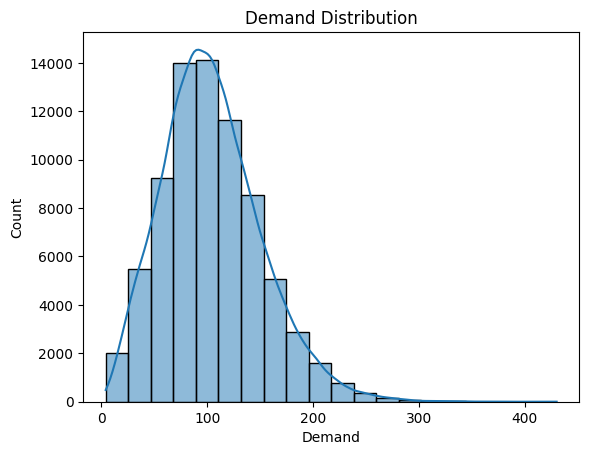

In [21]:
import seaborn as sns
import matplotlib.pyplot as plt
sns.histplot(df['Demand'], bins = 20, kde = True)
plt.title('Demand Distribution')
plt.show();

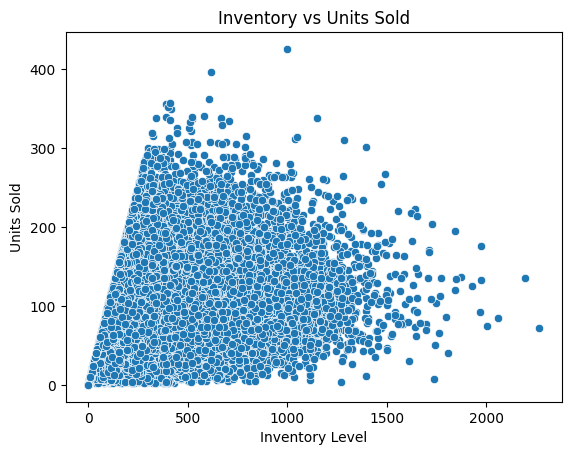

In [22]:
sns.scatterplot(data = df, x = 'Inventory Level', y = 'Units Sold' )
plt.title('Inventory vs Units Sold')
plt.show();

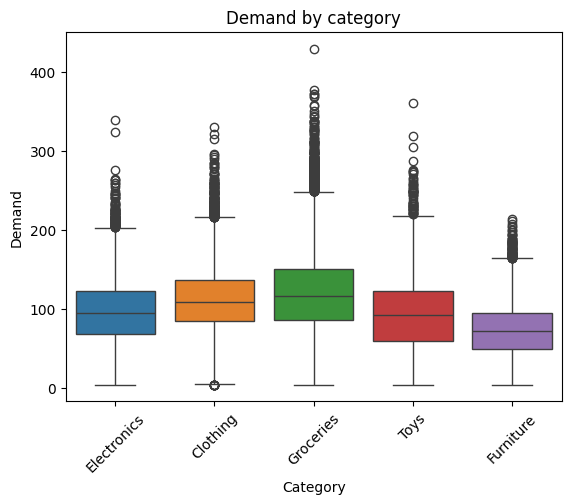

In [23]:
sns.boxplot(data = df, x= 'Category', y = 'Demand', hue  ='Category')
plt.xticks(rotation = 45)
plt.title('Demand by category')
plt.show()

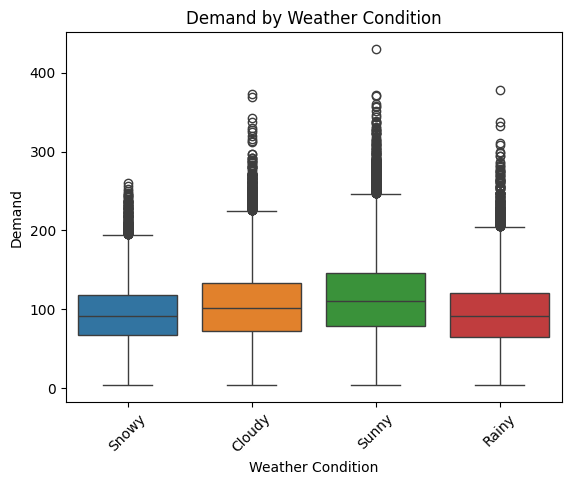

In [24]:
sns.boxplot(data = df, x= 'Weather Condition', y = 'Demand', hue  ='Weather Condition')
plt.xticks(rotation = 45)
plt.title('Demand by Weather Condition')
plt.show()

In [25]:
monthly_demand = df.groupby('Month')['Demand'].mean()

In [26]:
monthly_demand

Month
1     106.040000
2      92.882500
3     113.613871
4      92.816667
5      86.521129
6     117.346000
7     101.561613
8     119.803387
9     107.431500
10     95.557258
11    107.542333
12    109.003226
Name: Demand, dtype: float64

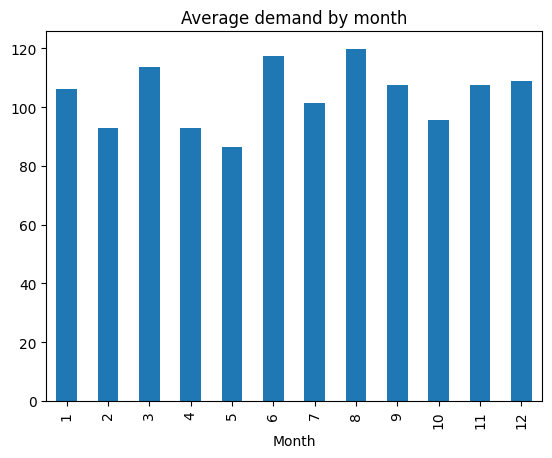

In [27]:
monthly_demand.plot(kind = 'bar')
plt.title('Average demand by month')
plt.show();

In [28]:
daily_demand = df.groupby('Date')['Demand'].sum()
daily_demand

Date
2022-01-01    10060
2022-01-02    10814
2022-01-03    11317
2022-01-04    11469
2022-01-05    11724
              ...  
2024-01-26    11182
2024-01-27    11540
2024-01-28    11440
2024-01-29    10268
2024-01-30     9657
Name: Demand, Length: 760, dtype: int64

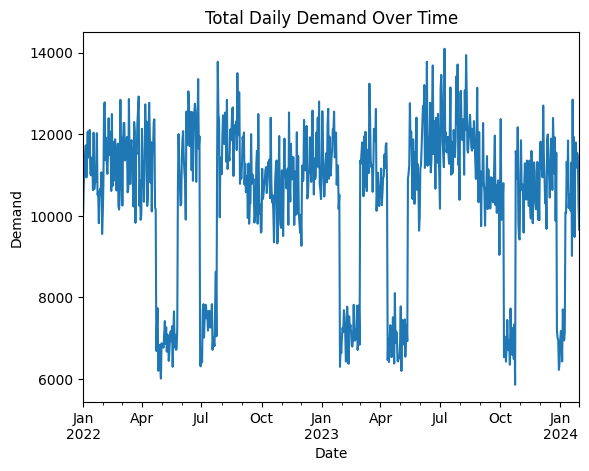

In [29]:
daily_demand.plot()
plt.title('Total Daily Demand Over Time')
plt.xlabel('Date')
plt.ylabel('Demand')
plt.show();

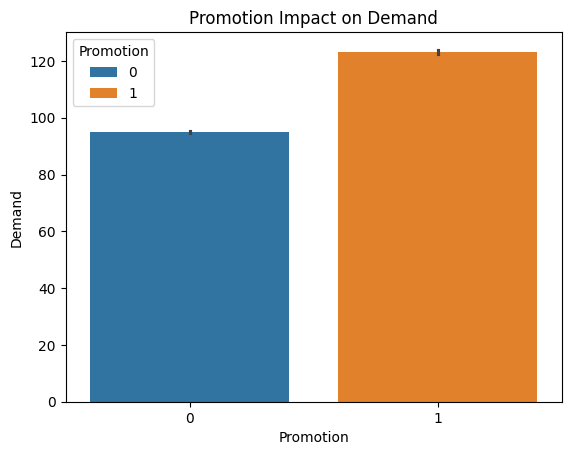

In [30]:
sns.barplot(data = df, x ='Promotion', y = 'Demand', hue = 'Promotion')
plt.title('Promotion Impact on Demand')
plt.show();

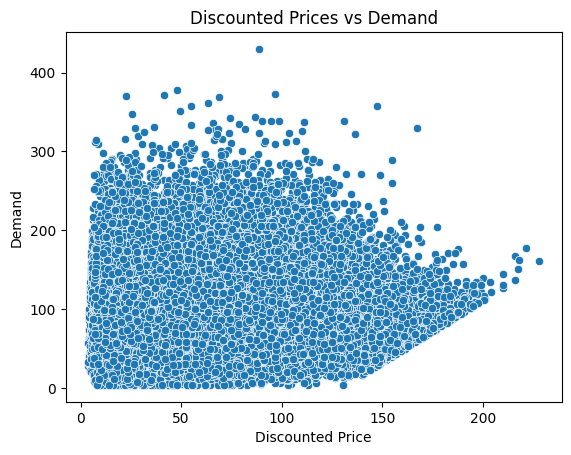

In [31]:
sns.scatterplot(data = df, x = 'Discounted Price', y='Demand')
plt.title('Discounted Prices vs Demand')
plt.show();

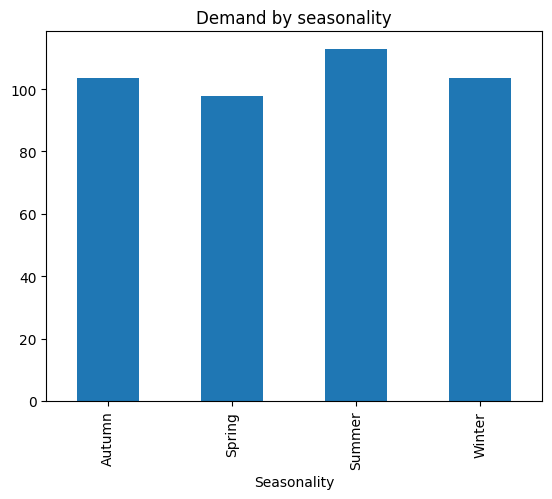

In [32]:
df.groupby('Seasonality')['Demand'].mean().plot(kind = 'bar', title = 'Demand by seasonality')
plt.show();

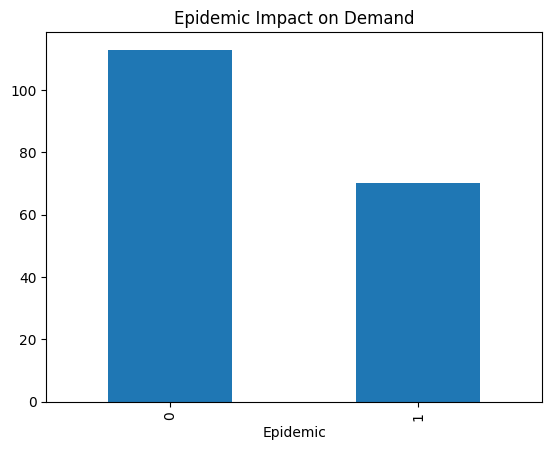

In [33]:
df.groupby('Epidemic')['Demand'].mean().plot(kind = 'bar', title = 'Epidemic Impact on Demand')
plt.show();

In [34]:
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from xgboost import XGBRegressor

In [35]:
features = ['Price','Discount','Inventory Level','Promotion','Competitor Pricing','Category']

In [36]:
features

['Price',
 'Discount',
 'Inventory Level',
 'Promotion',
 'Competitor Pricing',
 'Category']

In [37]:
target = 'Demand'

In [38]:
X = df[features].copy()

In [39]:
X

,Price,Discount,Inventory Level,Promotion,Competitor Pricing,Category
0,72.72,5,195,0,85.73,Electronics
1,80.16,15,117,1,92.02,Clothing
2,62.94,10,247,1,60.08,Clothing
3,87.63,10,139,0,85.19,Electronics
4,54.41,0,152,0,51.63,Groceries
...,...,...,...,...,...,...
75995,29.80,5,233,0,32.23,Toys
75996,42.92,5,137,0,40.73,Toys
75997,17.81,10,197,0,19.41,Clothing
75998,151.72,0,125,0,143.71,Furniture


In [40]:
y = df[target]

In [41]:
y

0        115
1        229
2        157
3         52
4         59
        ... 
75995     64
75996    137
75997     68
75998     84
75999     73
Name: Demand, Length: 76000, dtype: int64

In [42]:
label_encoders = {}
categorical_cols = X.select_dtypes(include = 'object').columns
categorical_cols

Index(['Category'], dtype='object')

In [43]:
for col in categorical_cols:
    le = LabelEncoder()
    X[col] = le.fit_transform(X[col])
    label_encoders[col] = le

In [44]:
label_encoders

{'Category': LabelEncoder()}

In [45]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.20)

In [46]:
xgb = XGBRegressor(objective = 'reg:squarederror', n_jobs = -1)

In [47]:
param_dict={
    'n_estimators':[200,300,500],
    'max_depth':[3,4,6,8],
    'learning_rate':[0.01,0.05,0.1],
    'subsample':[0.7,0.8,1.0],
    'colsample_bytree':[0.7,0.8,1.0],
    'min_child_weight':[1,3,5]
}

In [48]:
random_search = RandomizedSearchCV(
    estimator = xgb,
    param_distributions = param_dict,
    n_iter = 25,
    scoring = 'neg_mean_absolute_error',
    cv = 3,
    verbose = 1,
    n_jobs = -1
)

In [49]:
random_search.fit(X_train, y_train)

Fitting 3 folds for each of 25 candidates, totalling 75 fits


RandomizedSearchCV(cv=3,
                   estimator=XGBRegressor(base_score=None, booster=None,
                                          callbacks=None,
                                          colsample_bylevel=None,
                                          colsample_bynode=None,
                                          colsample_bytree=None, device=None,
                                          early_stopping_rounds=None,
                                          enable_categorical=False,
                                          eval_metric=None, feature_types=None,
                                          feature_weights=None, gamma=None,
                                          grow_policy=None,
                                          importance_type=None,
                                          interaction_constraint...
                                          monotone_constraints=None,
                                          multi_strategy=None,
                                          n_estimators=None, n_jobs=-1,
                                          num_parallel_tree=None, ...),
                   n_iter=25, n_jobs=-1,
                   param_distributions={'colsample_bytree': [0.7, 0.8, 1.0],
                                        'learning_rate': [0.01, 0.05, 0.1],
                                        'max_depth': [3, 4, 6, 8],
                                        'min_child_weight': [1, 3, 5],
                                        'n_estimators': [200, 300, 500],
                                        'subsample': [0.7, 0.8, 1.0]},
                   scoring='neg_mean_absolute_error', verbose=1)

In [50]:
random_search.best_params_

{'subsample': 0.8,
 'n_estimators': 500,
 'min_child_weight': 3,
 'max_depth': 6,
 'learning_rate': 0.05,
 'colsample_bytree': 1.0}

In [51]:
best_model = random_search.best_estimator_

In [52]:
y_pred = best_model.predict(X_test)

In [53]:
from sklearn.metrics import root_mean_squared_error
root_mean_squared_error(y_test, y_pred)

35.537052154541016

In [54]:
best_model.feature_importances_

array([0.08923388, 0.02646771, 0.02251135, 0.59680796, 0.03037112,
       0.23460801], dtype=float32)

In [55]:
features_importance = pd.Series(
    best_model.feature_importances_,
    index = X.columns
).sort_values(ascending = False)

<Axes: title={'center': 'Feature Importances'}>

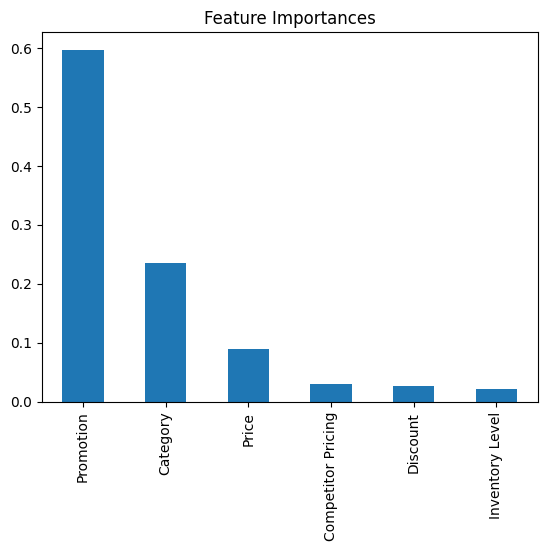

In [56]:
features_importance.plot(kind ='bar', title ='Feature Importances')

In [57]:
!pip install streamlit
import streamlit as st

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 67.1 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.3/11.3 MB 85.0 MB/s eta 0:00:00:00:010:01


### DESPLIEGUE DE APP VIA GRADIO

In [58]:

import gradio as gr
import pandas as pd

def predict(price, discount, inventory_level, promotion, competitor_pricing, category):
    input_data = pd.DataFrame({
        "Price": [price],
        "Discount": [discount],
        "Inventory Level": [inventory_level],
        "Promotion": [promotion],
        "Competitor Pricing": [competitor_pricing],
        "Category": [category]
    })

    for col, encoder in label_encoders.items():
        if col in input_data.columns:
            input_data[col] = encoder.transform(input_data[col])

    prediction = best_model.predict(input_data)[0]
    return int(prediction)

iface = gr.Interface(
    fn=predict,
    inputs=[
        gr.Number(label="Price", value=50),
        gr.Number(label="Discount (%)", value=10),
        gr.Number(label="Inventory Level", value=100),
        gr.Dropdown([0,1], label="Promotion"),
        gr.Number(label="Competitor Pricing", value=50),
        gr.Dropdown(label_encoders["Category"].classes_.tolist(), label="Category"),
    ],
    outputs=gr.Number(label="Predicted Demand"),
    title="Demand Forecasting App"
)

iface.launch()


* Running on local URL:  http://127.0.0.1:7860
It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

* Running on public URL: https://1c74e3833de54573d4.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


### EXTRA VIA STREAMLIT

In [59]:
st.title("Demand Forescasting App")
st.divider()
st.header("Input Features")
price = st.number_input("Prices", min_value = 0.0, value = 50 )
discount = st.number_input("Discount(%)",min_value = 0, max_value = 100, value = 10)
inventory_level = st.number_input("Inventory_level", min_value = 0, value = 100 )
promotion = st.selectbox("Promotion", [0,1])
competitor_pricing = st.number_input("Competitor Price", min_value =0.0, value = 50)
category = st.selectbox("Category", label_encoders["Category"].clasess_.tolist())

input_data = pd.DataFrame({
    "Price": [price],
    "Discount":[discount],
    "Inventory Level":[inventory_level],
    "Promotion":[promotion],
    "Competitor Pricing":[competitor_pricing],
    "Category":[category]
})

for col, encoder in label_encoders.items():
    if col in input_data.columns:
        input_data[col] = encoder.transform(input_data[col])

st.divider()
if st.button("Predict Demand"):
    prediction = model.predict(input_data)[0]
    st.success(f"Predict Demand:{int(prediction)}")

2026-04-19 22:22:16.195 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-19 22:22:16.476 
  command:

    streamlit run /usr/local/lib/python3.12/dist-packages/colab_kernel_launcher.py [ARGUMENTS]
2026-04-19 22:22:16.477 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-19 22:22:16.478 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-19 22:22:16.479 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-19 22:22:16.480 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-19 22:22:16.480 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-19 22:22:16.481 Thread 'MainThread': mi

StreamlitMixedNumericTypesError: All numerical arguments must be of the same type.
`value` has int type.
`min_value` has float type.

In [60]:
import joblib


joblib.dump(label_encoders, "label_encoders.pkl")

['label_encoders.pkl']

In [61]:
joblib.dump(best_model, "model.pkl")

['model.pkl']

In [62]:

%%writefile app.py
import gradio as gr
import pandas as pd
import joblib

model = joblib.load("model.pkl")
label_encoders = joblib.load("label_encoders.pkl")

def predict(price, discount, inventory_level, promotion, competitor_pricing, category):
    input_data = pd.DataFrame({
        "Price": [price],
        "Discount": [discount],
        "Inventory Level": [inventory_level],
        "Promotion": [promotion],
        "Competitor Pricing": [competitor_pricing],
        "Category": [category]
    })

    for col, encoder in label_encoders.items():
        if col in input_data.columns:
            input_data[col] = encoder.transform(input_data[col])

    return int(model.predict(input_data)[0])

demo = gr.Interface(
    fn=predict,
    inputs=[
        gr.Number(value=50, label="Price"),
        gr.Number(value=10, label="Discount (%)"),
        gr.Number(value=100, label="Inventory Level"),
        gr.Dropdown([0,1], label="Promotion"),
        gr.Number(value=50, label="Competitor Pricing"),
        gr.Dropdown(
            label_encoders["Category"].classes_.tolist(),
            label="Category"
        ),
    ],
    outputs=gr.Number(label="Predicted Demand"),
    title="Demand Forecasting App"
)

demo.launch()


Writing app.py


In [64]:

%%writefile requirements.txt
gradio
pandas
scikit-learn
joblib

Writing requirements.txt
